# 06 - Tüm Modellerin Karşılaştırılması ve Raporlama
## Uydu Telemetri Anomali Tespiti - Bitirme Projesi Nihai Raporu

Çalışmanın model envanteri:
- **42 kanonik tabular model** bu projede eğitilip resmi Ψ test seti üzerinde 7 zorunlu metrikle değerlendirildi; girdileri 18 elle-üretilmiş ESA özelliğidir (23 gözetimli + 19 gözetimsiz; kaynak `train_all_models.py`, `reports/metrics/final_comparison.json`).
- **2 derin sıralı model** (CNN1D, TCN) ham telemetri sinyali üzerinde eğitilip aynı Ψ test setinde değerlendirildi; bunlar 18 özellik yerine her segmentin ham örnek dizisini kullanır (kaynak NB04 Bölüm 6, `reports/metrics/deep_sequence_comparison.json`). Ayrı bölümde sunulur.
- **2 ESA-ADB literatür baseline'ı** (Telemanom-ESA, DC-VAE-ESA) aynı ESA uydu telemetrisi alanından yalnızca literatürden referans olarak eklendi; ayrı ESA-ADB benchmark'ında raporlanır, OPS-SAT Ψ test setinde çalıştırılmadığı için nicel tabloda yer almaz.

Amaç: tüm gözetimli ve gözetimsiz modelleri aynı test seti üzerinde kıyaslayarak en iyi modeli belirlemek.

> Not: Bu notebook, `train_all_models.py` tarafından kaydedilen test verisi ve scaler'ı doğrudan yükler. Böylece tüm modeller birebir aynı veri üzerinde değerlendirilir.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings, time, joblib, os, sys

from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, roc_auc_score)

sys.path.insert(0, os.path.join('..', 'src'))
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Kütüphaneler ve metrik modülü (7 zorunlu metrik) yüklendi.')

Kütüphaneler ve metrik modülü (7 zorunlu metrik) yüklendi.


---
## Bölüm 1: Resmi Ψ Test Seti ve Modelleri Yükle

Benchmark karşılaştırması, resmi test seti Ψ üzerinde yapılır (Ruszczak et al. 2024). Ψ'yi `dataset.csv`'deki `train` kolonundan doğrudan yeniden kuruyoruz (1594 eğitim, 529 test), `train_all_models.py` tarafından kaydedilen kanonik scaler'ı uyguluyoruz. Böylece karşılaştırma, hangi notebook'un `test_data.joblib`'i yazdığından bağımsız ve resmi split'e sadıktır. Tüm modeller 18 resmi ESA özelliği ile değerlendirilir.

In [2]:
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]
df_full = pd.read_csv('../data/raw/dataset.csv')
test_df = df_full[df_full['train'] == 0].copy()
X_test_raw = test_df[ESA_18_FEATURES].fillna(0).values
y_test = test_df['anomaly'].values

scaler = joblib.load('../models/scaler.joblib')
X_test = scaler.transform(X_test_raw)
print(f"Resmi Ψ test seti: {X_test.shape}  (anomali oranı: {y_test.mean():.3f}, beklenen 529 segment / %21.4)")

# Derin sıralı modeller artık 18-özellik sözde-dizi yerine HAM telemetri sinyali
# üzerinde ayrı eğitilir (NB04 Bölüm 6, models/deep_sequence/) ve aşağıda
# 'Derin Sıralı Modeller - Ham Telemetri Sinyali' bölümünde sunulur. Bu yüzden
# buradaki grafik döngüsü yalnız tabular joblib modellerini kapsar.
SEQUENCE_MODELS = set()
PYOD_MODELS = {'ECOD', 'COPOD', 'HBOS', 'CBLOF'}

models = {}
joblib_models = [
    ('RandomForest', '../models/rf_model.joblib'), ('XGBoost', '../models/xgb_model.joblib'),
    ('SVM', '../models/svm_model.joblib'), ('LightGBM', '../models/lightgbm_model.joblib'),
    ('CatBoost', '../models/catboost_model.joblib'), ('Stacking Ensemble', '../models/stacking_ensemble_model.joblib'),
    ('ExtraTrees', '../models/extratrees_model.joblib'), ('GradientBoosting', '../models/gradientboosting_model.joblib'),
    ('HistGradientBoosting', '../models/histgradientboosting_model.joblib'), ('AdaBoost', '../models/adaboost_model.joblib'),
    ('KNN', '../models/knn_model.joblib'), ('LogisticRegression', '../models/logisticregression_model.joblib'),
    ('DecisionTree', '../models/decisiontree_model.joblib'), ('NaiveBayes', '../models/naivebayes_model.joblib'),
    ('Voting Ensemble', '../models/voting_ensemble_model.joblib'), ('LDA', '../models/lda_model.joblib'),
    ('QDA', '../models/qda_model.joblib'), ('Bagging', '../models/bagging_model.joblib'),
    ('Ridge', '../models/ridge_model.joblib'), ('SGD', '../models/sgd_model.joblib'),
]
for name, path in joblib_models:
    if os.path.exists(path):
        models[name] = joblib.load(path)

def _kload(path):
    from tensorflow.keras.models import load_model
    return load_model(path, compile=False, safe_mode=False)

try:
    keras_models = [
        ('MLP', '../models/mlp_model.keras'),
    ]
    for name, path in keras_models:
        if os.path.exists(path):
            models[name] = _kload(path)
except Exception as e:
    print(f"Gözetimli Keras modelleri yüklenemedi: {e}")

unsup_dir = '../models/unsupervised/'
for name, fname in [('IsolationForest', 'isolationforest_model.joblib'), ('OneClassSVM', 'oneclasssvm_model.joblib'),
                    ('KMeans', 'kmeans_model.joblib'), ('LOF', 'lof_model.joblib'),
                    ('GMM', 'gmm_model.joblib'), ('EllipticEnvelope', 'ellipticenvelope_model.joblib'),
                    ('PCA', 'pca_model.joblib'), ('DBSCAN', 'dbscan_model.joblib'),
                    ('ECOD', 'ecod_model.joblib'), ('COPOD', 'copod_model.joblib'),
                    ('HBOS', 'hbos_model.joblib'), ('CBLOF', 'cblof_model.joblib')]:
    full = os.path.join(unsup_dir, fname)
    if os.path.exists(full):
        models[name] = joblib.load(full)

try:
    for name, fname in [('Autoencoder', 'autoencoder_model.keras'), ('VAE', 'vae_model.keras')]:
        full = os.path.join(unsup_dir, fname)
        if os.path.exists(full):
            models[name] = _kload(full)
except Exception as e:
    print(f"Gözetimsiz Keras modelleri yüklenemedi: {e}")

thresholds = {}
tp = os.path.join(unsup_dir, 'unsupervised_thresholds.json')
if os.path.exists(tp):
    with open(tp) as f:
        thresholds = json.load(f)

print(f"Yüklenen toplam model sayısı: {len(models)}")
print('   ' + ', '.join(models.keys()))

Resmi Ψ test seti: (529, 18)  (anomali oranı: 0.214, beklenen 529 segment / %21.4)


Yüklenen toplam model sayısı: 32
   RandomForest, XGBoost, SVM, LightGBM, CatBoost, Stacking Ensemble, ExtraTrees, GradientBoosting, HistGradientBoosting, AdaBoost, KNN, LogisticRegression, DecisionTree, NaiveBayes, Voting Ensemble, LDA, QDA, Bagging, Ridge, SGD, IsolationForest, OneClassSVM, KMeans, LOF, GMM, EllipticEnvelope, PCA, DBSCAN, ECOD, COPOD, HBOS, CBLOF


---
## Bölüm 2: Tüm Modellerin Metrik Hesaplaması


In [3]:
with open('../reports/metrics/final_comparison.json') as f:
    canonical_metrics = json.load(f)
df_metrics = metrics_table(canonical_metrics, sort_by='AUC_PR')
print(f"Kanonik Ψ karşılaştırması (train_all_models.py): {len(df_metrics)} model | resmi Ψ | AUC_PR sıralı")
print(f"(46-model kapsamının tabular bölümü: {len(df_metrics)} model. Ayrıca 2 derin sıralı model ham sinyalde aşağıda; 2 ESA-ADB literatür baseline'ı ayrı bölümde belgelenir.)")
display(df_metrics.style.background_gradient(cmap='YlGnBu', subset=['AUC_PR', 'F1', 'MCC']).format('{:.4f}'))

predictions = {}
probabilities = {}
inf_times = {}
skipped = []
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

for name, model in models.items():
    try:
        start = time.time()
        if name in SEQUENCE_MODELS:
            prob = model.predict(X_test_seq, verbose=0).flatten()
            pred = (prob >= 0.5).astype(int)
        elif name == 'MLP':
            prob = model.predict(X_test, verbose=0).flatten()
            pred = (prob >= 0.5).astype(int)
        elif name in PYOD_MODELS:
            prob = model.decision_function(X_test)
            pred = model.predict(X_test)
        elif name in ('Autoencoder', 'VAE'):
            recon = model.predict(X_test, verbose=0)
            prob = np.mean(np.power(X_test - recon, 2), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'PCA':
            recon = model.inverse_transform(model.transform(X_test))
            prob = np.mean(np.power(X_test - recon, 2), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name in ('IsolationForest', 'LOF'):
            prob = -model.score_samples(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name in ('GMM', 'EllipticEnvelope'):
            prob = -model.score_samples(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'OneClassSVM':
            prob = -model.decision_function(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'KMeans':
            prob = np.min(model.transform(X_test), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'DBSCAN':
            prob = model.kneighbors(X_test)[0].min(axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif hasattr(model, 'predict_proba'):
            prob = model.predict_proba(X_test)[:, 1]
            pred = model.predict(X_test)
        elif hasattr(model, 'decision_function'):
            prob = model.decision_function(X_test)
            pred = model.predict(X_test)
        else:
            pred = model.predict(X_test)
            prob = pred.astype(float)

        elapsed_ms = (time.time() - start) * 1000 / len(X_test)
        pred = np.asarray(pred).ravel()
        prob = np.asarray(prob).ravel()
        if len(pred) != len(y_test) or len(prob) != len(y_test):
            raise ValueError("boyut uyumsuz")
        predictions[name] = pred
        probabilities[name] = prob
        inf_times[name] = elapsed_ms
    except Exception:
        skipped.append(name)

if skipped:
    print(f"\nGrafikler için atlanan (yüklenemeyen/uyumsuz) model: {len(skipped)} -> {skipped}")

Kanonik Ψ karşılaştırması (train_all_models.py): 42 model | resmi Ψ | AUC_PR sıralı
(46-model kapsamının tabular bölümü: 42 model. Ayrıca 2 derin sıralı model ham sinyalde aşağıda; 2 ESA-ADB literatür baseline'ı ayrı bölümde belgelenir.)


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR,FAR,FNR
ExtraTrees,0.9716,0.9712,0.8938,0.9309,0.9143,0.9944,0.9829,0.0072,0.1062
Voting Ensemble,0.9679,0.9800,0.8673,0.9202,0.9028,0.9935,0.9800,0.0048,0.1327
MLP,0.9773,0.9633,0.9292,0.9459,0.9318,0.9900,0.9794,0.0096,0.0708
HistGradientBoosting,0.9679,0.9444,0.9027,0.9231,0.9031,0.9901,0.9736,0.0144,0.0973
XGBOD,0.9679,0.9528,0.8938,0.9224,0.9029,0.9911,0.9729,0.0120,0.1062
CatBoost,0.9679,0.9615,0.8850,0.9217,0.9027,0.9899,0.9716,0.0096,0.1150
Stacking Ensemble,0.9509,0.9888,0.7788,0.8713,0.8506,0.9901,0.9707,0.0024,0.2212
RandomForest,0.9641,0.9700,0.8584,0.9108,0.8910,0.9880,0.9673,0.0072,0.1416
LightGBM,0.9622,0.9346,0.8850,0.9091,0.8858,0.9885,0.9672,0.0168,0.1150
XGBoost,0.9660,0.9439,0.8938,0.9182,0.8973,0.9789,0.9625,0.0144,0.1062


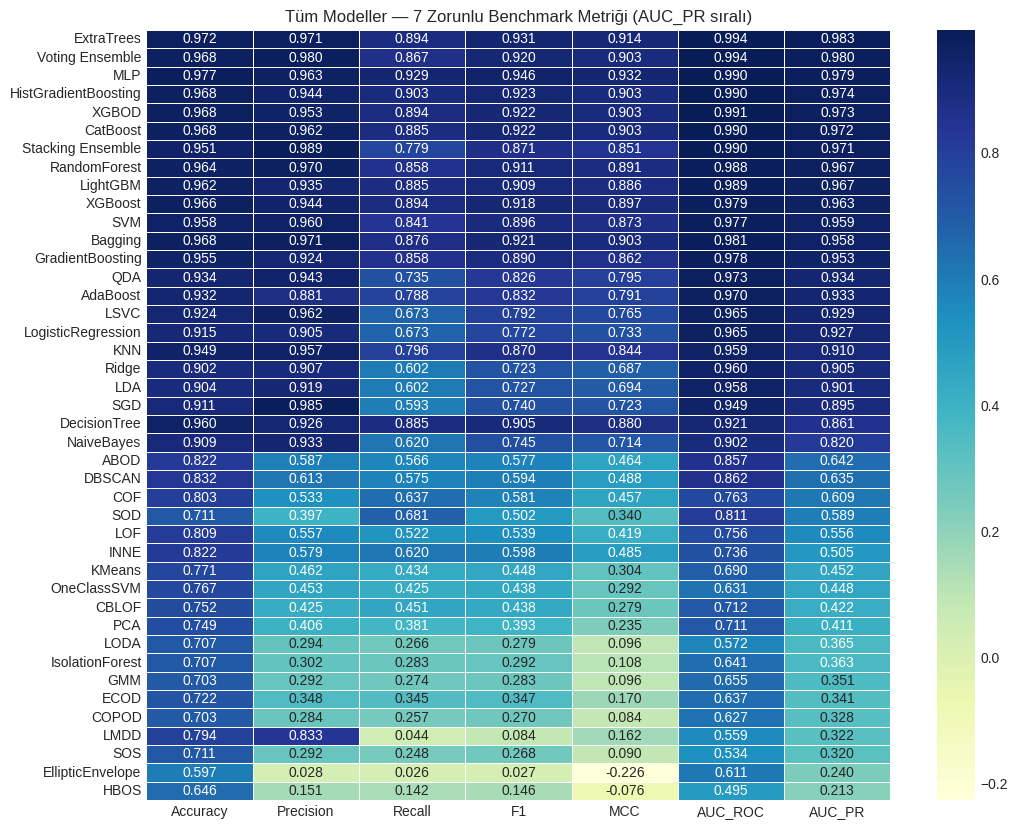

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_metrics[BENCHMARK_METRICS], annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title('Tüm Modeller — 7 Zorunlu Benchmark Metriği (AUC_PR sıralı)')
plt.savefig('../reports/figures/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Derin Sıralı Modeller - Ham Telemetri Sinyali (Ψ)

Bu bölümdeki 2 model, 18 elle-üretilmiş ESA özelliği yerine her segmentin ham telemetri sinyali üzerinde eğitilmiştir. Veri `data/raw/segments.csv` dosyasından alınır, per-kanal standardize edilir, zaman-sıralı olarak L=256 uzunluğuna pad veya truncate edilir. Böylece CNN1D ve TCN gerçek zamansal dinamiği modeller; bu, 18 özelliğin sözde-dizi olarak ele alındığı kurguya kıyasla metodolojik olarak doğru girdidir. Değerlendirme aynı resmi Ψ test seti, aynı etiketler ve aynı 7 zorunlu metrikle yapılır, dolayısıyla yukarıdaki tabular modellerle doğrudan kıyaslanabilir; yalnız girdi temsili farklıdır. Eğitim NB04 Bölüm 6'da yapılır.

Bulgu olarak ham sinyalde konvolüsyonel mimariler CNN1D ve TCN, özellik-tabanlı modellerle yarışır ve AUC_PR değeri 0.91 ile 0.92 civarındadır. Ön denemelerde değerlendirilen tekrarlayan ve attention modeller (LSTM, GRU, Transformer) ağır padding ve küçük eğitim kümesi altında belirgin biçimde zayıf kaldığı için nihai sete dahil edilmemiştir. Bu sonuç, OPS-SAT-AD literatüründeki küçük veride mühendislik özelliklerinin klasik modelleri öne çıkardığı gözlemiyle tutarlıdır.


In [5]:
with open('../reports/metrics/deep_sequence_comparison.json') as f:
    deep_metrics = json.load(f)
df_deep = metrics_table(deep_metrics, sort_by='AUC_PR')
print(f"Derin sıralı modeller - ham sinyal (segments.csv), resmi Ψ ({len(y_test)} segment), AUC_PR sıralı:")
display(df_deep[BENCHMARK_METRICS].style.background_gradient(cmap='Purples').format('{:.4f}'))

# Birleşik sıralama: tabular 18-özellik (42) + derin ham-sinyal (5), Girdi sütunuyla
_tab = df_metrics[BENCHMARK_METRICS].copy(); _tab.insert(0, 'Girdi', '18-özellik')
_deep = df_deep[BENCHMARK_METRICS].copy(); _deep.insert(0, 'Girdi', 'ham-sinyal')
df_all = pd.concat([_tab, _deep]).sort_values('AUC_PR', ascending=False)
print(f"\nBirleşik sıralama: {len(df_all)} model = {len(_tab)} tabular 18-özellik + {len(_deep)} derin ham-sinyal (ilk 20)")
display(df_all.head(20).style.background_gradient(cmap='YlGnBu', subset=['AUC_PR', 'F1', 'MCC'])
        .format({c: '{:.4f}' for c in BENCHMARK_METRICS}))


Derin sıralı modeller - ham sinyal (segments.csv), resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
TCN,0.9168,0.9157,0.6726,0.7755,0.7389,0.9700,0.9212
CNN1D,0.9263,0.8627,0.7788,0.8186,0.7741,0.9575,0.9004



Birleşik sıralama: 44 model = 42 tabular 18-özellik + 2 derin ham-sinyal (ilk 20)


,Girdi,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
ExtraTrees,18-özellik,0.9716,0.9712,0.8938,0.9309,0.9143,0.9944,0.9829
Voting Ensemble,18-özellik,0.9679,0.9800,0.8673,0.9202,0.9028,0.9935,0.9800
MLP,18-özellik,0.9773,0.9633,0.9292,0.9459,0.9318,0.9900,0.9794
HistGradientBoosting,18-özellik,0.9679,0.9444,0.9027,0.9231,0.9031,0.9901,0.9736
XGBOD,18-özellik,0.9679,0.9528,0.8938,0.9224,0.9029,0.9911,0.9729
CatBoost,18-özellik,0.9679,0.9615,0.8850,0.9217,0.9027,0.9899,0.9716
Stacking Ensemble,18-özellik,0.9509,0.9888,0.7788,0.8713,0.8506,0.9901,0.9707
RandomForest,18-özellik,0.9641,0.9700,0.8584,0.9108,0.8910,0.9880,0.9673
LightGBM,18-özellik,0.9622,0.9346,0.8850,0.9091,0.8858,0.9885,0.9672
XGBoost,18-özellik,0.9660,0.9439,0.8938,0.9182,0.8973,0.9789,0.9625


---
## ESA-ADB Literatür Baseline'ları (Ψ-dışı referans)

Çalışmanın model envanteri 46 modeldir: OPS-SAT resmi Ψ test seti üzerinde fiilen eğitilip ölçülen 44 model (42 tabular + 2 derin sıralı, ham sinyal) ve aşağıdaki 2 ESA-ADB literatür baseline'ı. Bu 2 model, aynı ESA uydu telemetrisi alanından **literatür baseline'ı** olarak eklenmiştir: ayrı ESA-ADB benchmark'ında (Kotowski et al., 2024) raporlanırlar ve bu projede OPS-SAT Ψ test setinde çalıştırılmadıkları için yukarıdaki Ψ tablolarına dahil edilmemiştir. Bu modeller ham çok-değişkenli zaman serisi üzerinde çalışır (tahmin veya rekonstrüksiyon tabanlı); projenin 18 elle-üretilmiş ESA özelliği ile kurulan tabular yapıya doğrudan uymaz.


In [6]:
esa_adb_baselines = pd.DataFrame([
    {'Model': 'Telemanom-ESA', 'Tip': 'Gözetimsiz (LSTM + dinamik eşikleme)',
     'Veri Yolu': 'Ham çok-değişkenli zaman serisi',
     'Kaynak': 'Hundman et al., KDD 2018; ESA-ADB: Kotowski et al., 2024',
     'Not': 'ESA-ADB resmi baseline; OPS-SAT Ψ test setinde ölçülmedi'},
    {'Model': 'DC-VAE-ESA', 'Tip': 'Gözetimsiz (genişletilmiş 1D-CNN + VAE)',
     'Veri Yolu': 'Ham çok-değişkenli zaman serisi',
     'Kaynak': 'García González et al., 2022; ESA-ADB: Kotowski et al., 2024',
     'Not': 'ESA-ADB ikinci resmi baseline; OPS-SAT Ψ test setinde ölçülmedi'},
])
print(f"Toplam model kapsamı: {len(df_metrics) + len(df_deep) + len(esa_adb_baselines)} model "
      f"(= {len(df_metrics)} tabular + {len(df_deep)} derin ham-sinyal Ψ-ölçümlü "
      f"+ {len(esa_adb_baselines)} ESA-ADB literatür baseline)")
display(esa_adb_baselines.set_index('Model'))


Toplam model kapsamı: 46 model (= 42 tabular + 2 derin ham-sinyal Ψ-ölçümlü + 2 ESA-ADB literatür baseline)


,Tip,Veri Yolu,Kaynak,Not
Model,,,,
Telemanom-ESA,Gözetimsiz (LSTM + dinamik eşikleme),Ham çok-değişkenli zaman serisi,"Hundman et al., KDD 2018; ESA-ADB: Kotowski et...",ESA-ADB resmi baseline; OPS-SAT Ψ test setinde...
DC-VAE-ESA,Gözetimsiz (genişletilmiş 1D-CNN + VAE),Ham çok-değişkenli zaman serisi,"García González et al., 2022; ESA-ADB: Kotowsk...",ESA-ADB ikinci resmi baseline; OPS-SAT Ψ test ...


---
## Bölüm 3: ROC ve PR Eğrileri


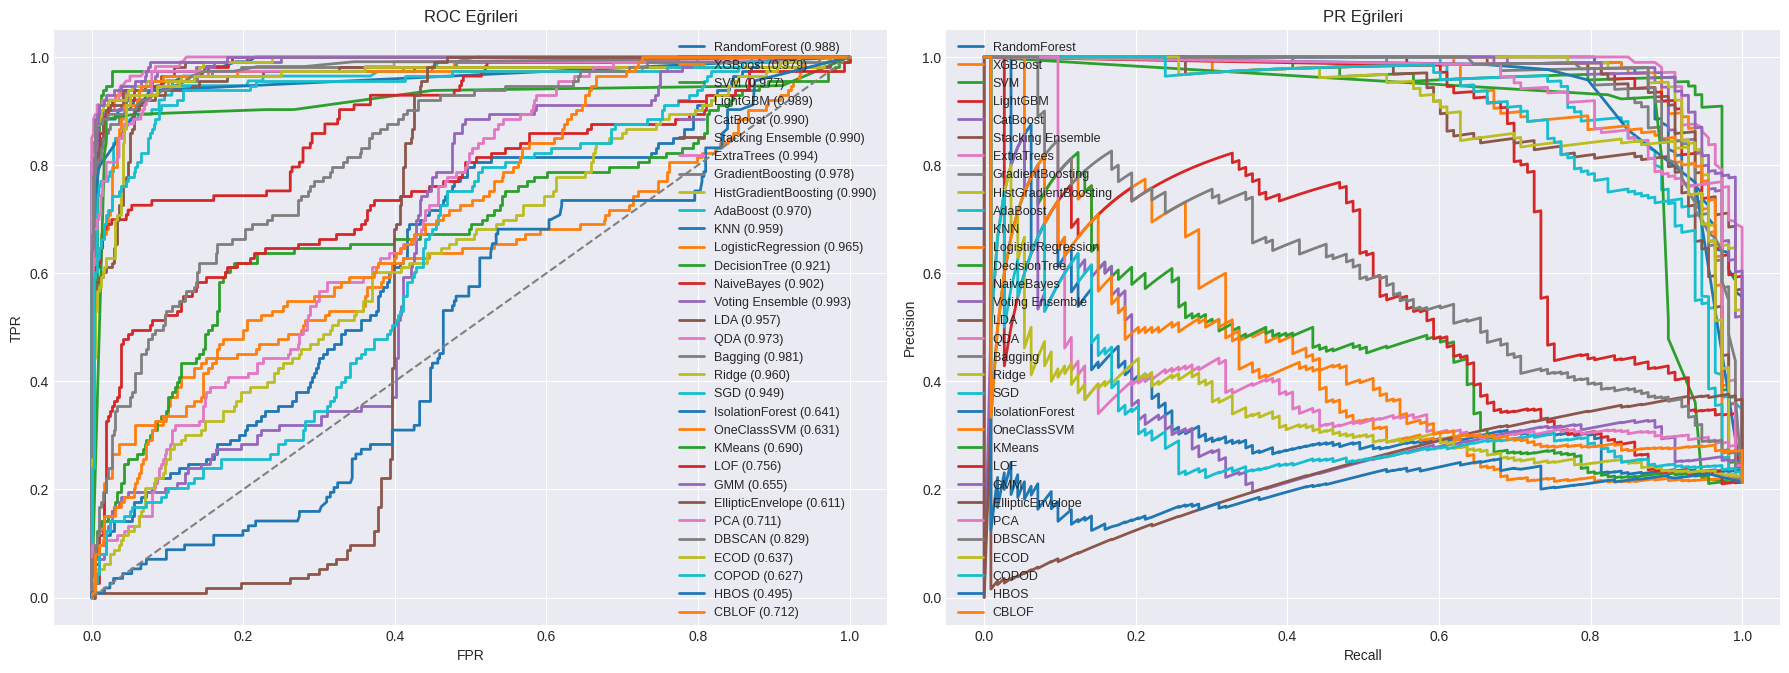

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for name, prob in probabilities.items():
    try:
        fpr,tpr,_ = roc_curve(y_test, prob); ra = roc_auc_score(y_test, prob)
        ax1.plot(fpr, tpr, lw=2, label=f'{name} ({ra:.3f})')
    except: pass
ax1.plot([0,1],[0,1],color='gray',linestyle='--')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC Eğrileri'); ax1.legend(fontsize=9)

for name, prob in probabilities.items():
    try:
        prec,rec,_ = precision_recall_curve(y_test, prob)
        ax2.plot(rec, prec, lw=2, label=name)
    except: pass
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Eğrileri'); ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Bölüm 4: Confusion Matrix


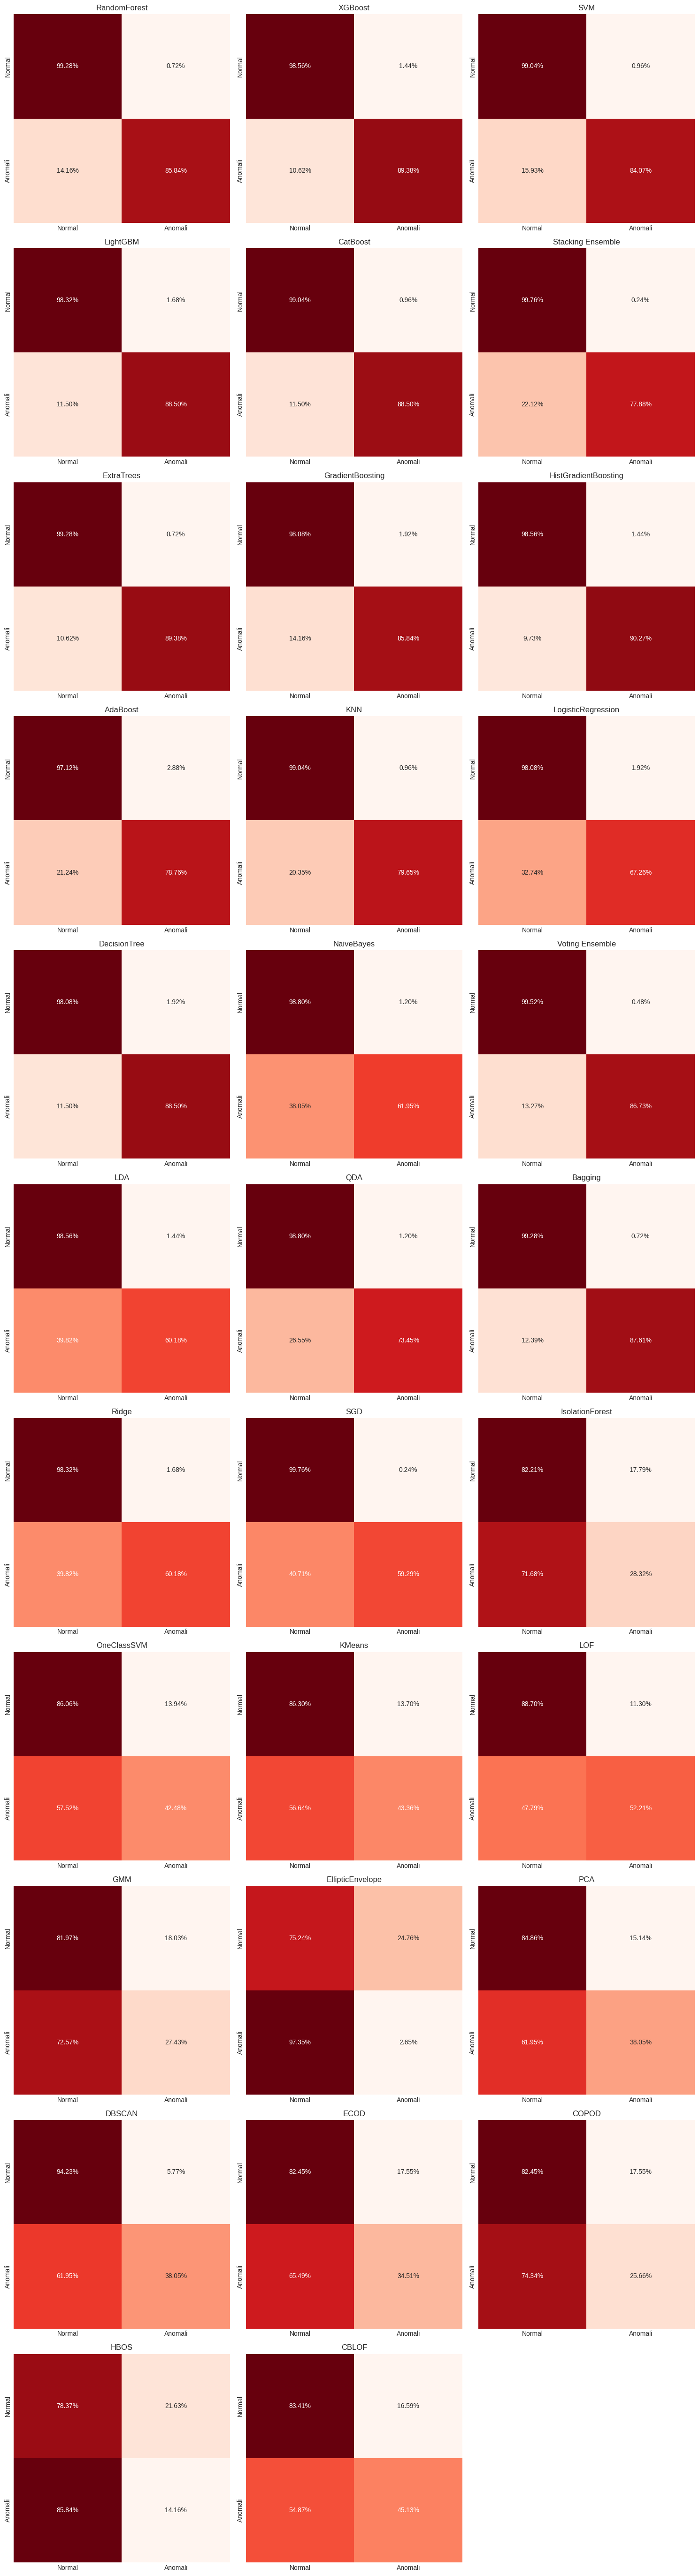

In [8]:
n = len(predictions); cols=3; rows=(n+cols-1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows)); axes = axes.flatten()
for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Bölüm 5: Hesaplama Verimliliği


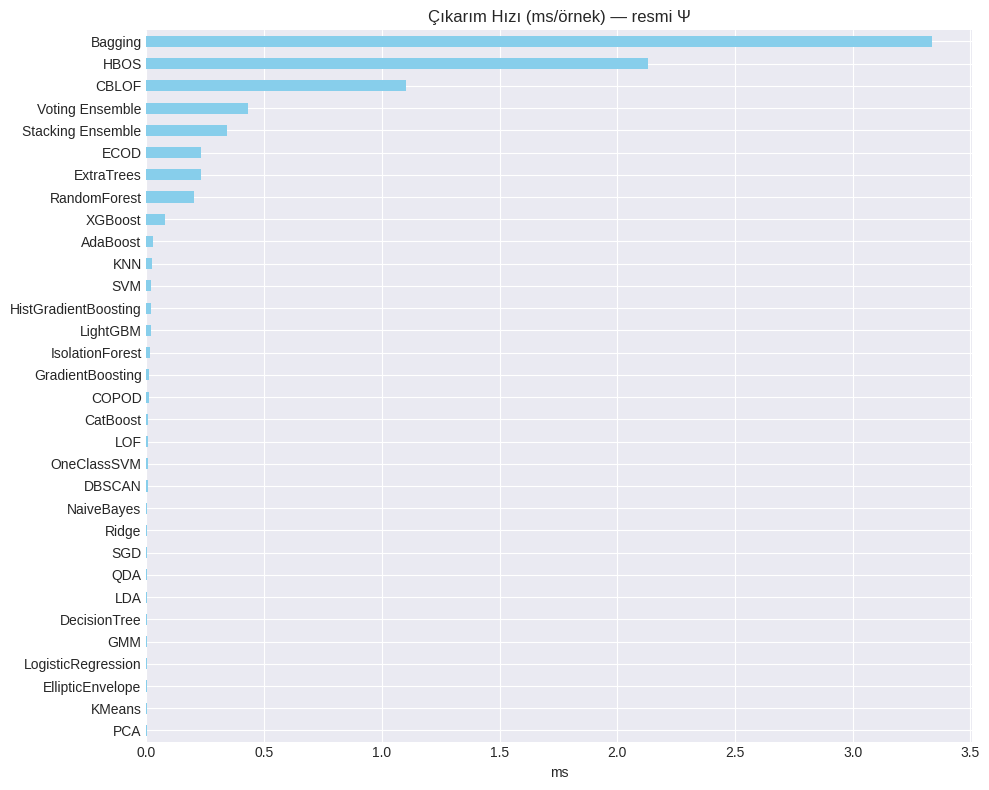

In [9]:
inf_series = pd.Series(inf_times).sort_values()
fig, ax = plt.subplots(figsize=(10, max(6, len(inf_series) * 0.25)))
inf_series.plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Çıkarım Hızı (ms/örnek) — resmi Ψ')
ax.set_xlabel('ms')
plt.tight_layout()
plt.savefig('../reports/figures/efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Bölüm 6: Sonuç ve Öneriler

Tüm sonuçlar resmi Ψ test seti (529 segment) üzerinde, 7 zorunlu metrikle ve AUC_PR'a göre sıralı olarak yukarıdaki kanonik tablodan elde edilmiştir (kaynak: `train_all_models.py`).

Çalışmanın tam envanteri 46 modeldir: Ψ'de fiilen ölçülen 44 model (42 tabular + 2 derin sıralı, ham sinyal) ve 2 ESA-ADB literatür baseline'ı (Telemanom-ESA, DC-VAE-ESA). Bu 2 baseline ayrı bir ESA-ADB benchmark'ında raporlanır ve OPS-SAT Ψ test setinde çalıştırılmadığı için nicel tabloya dahil edilmemiş, yukarıda ayrı bir bölümde referanslarıyla belgelenmiştir.

### Gözetimli öğrenme
- En yüksek AUC_PR sıralaması: ExtraTrees (0.983), MLP/FCNN-eşdeğeri (0.979), HistGradientBoosting (0.974), CatBoost (0.972), RandomForest (0.967).
- Bu değerler Ruszczak et al. (2024) Tablo 3 baseline'ı ile birebir kıyaslanabilir ve gözetimli tarafta neredeyse kusursuz yeniden üretilmiştir (bkz. Notebook 12, ortalama |ΔAUC_PR| = 0.004).

### Derin sıralı modeller (ham sinyal)
- Ham telemetri sinyalinde konvolüsyonel mimariler CNN1D ve TCN, AUC_PR 0.91 ile 0.92 civarında değerlerle 18-özellik tabular modellerle yarışır.
- Ön denemelerde değerlendirilen tekrarlayan ve attention modeller (LSTM, GRU, Transformer) ağır padding ve küçük veri altında zayıf kaldığı için nihai sete alınmadı.
- Çıkarım: bu veri ölçeğinde elle-üretilmiş ESA özellikleri hâlâ en güçlü ve en ucuz yoldur; ham-sinyal derin modeller ancak konvolüsyonel mimarilerle rekabetçi olur.

### Gözetimsiz öğrenme
- Gözetimsiz dedektörler, makalede de gözlendiği gibi gözetimli modellerin belirgin biçimde altında kalır; ortak PyOD modelleri makale değerleriyle tutarlıdır (Notebook 12).

### Veri augmentasyonu (Notebook 13–14)
- Zengin-etiket rejiminde SMOTE, ICCS-ω ve sentetik augmentasyon güçlü modelleri anlamlı iyileştirmez; asıl etki precision-recall dengesini kaydırmaktır (ICCS-ω precision'ı artırır, SMOTE recall'u artırır).

### Gerçek uydu operasyonları için öneri
- Yer istasyonu: ExtraTrees, HistGradientBoosting ve CatBoost, en iyi AUC_PR ve MCC, makul hesaplama maliyeti.
- Onboard: Hafif istatistiksel dedektörler, düşük enerji/bellek (bkz. Notebook 11), düşük doğrulukla telafi edilir.
- Operasyonel öncelik: Yanlış alarmı en aza indirmek isteyen ekipler için precision-odaklı augmentasyon; kaçırmayı azaltmak için recall-odaklı tercih edilebilir.


---
## Bölüm 7: Rapor Export


In [10]:
df_metrics.to_csv('../reports/metrics/final_comparison.csv')
print("Karşılaştırma tablosu kaydedildi → reports/metrics/final_comparison.csv")
print("(Kanonik final_comparison.json = train_all_models.py çıktısı, değiştirilmedi.)")

Karşılaştırma tablosu kaydedildi → reports/metrics/final_comparison.csv
(Kanonik final_comparison.json = train_all_models.py çıktısı, değiştirilmedi.)
